Imports:

In [1]:
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from torchvision import datasets
from torchvision.transforms import ToTensor

from torch.utils.data import random_split

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\torchvision\io\image.py:11: UserWarning: Failed to load image Python extension: Could not find module 'A:\ProgrammingStuff\Other\Anaconda3\Lib\site-packages\torchvision\image.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warn(f"Failed to load image Python extension: {e}")


In [2]:
def flatten(data):
    dataSize = len(data)
    x_flat = torch.zeros(dataSize, 784)
    y_flat = torch.zeros(dataSize)
    
    c = 0
    for img, lbl in data:
        img = torch.tensor(np.copy(img).reshape(784))
        lbl = torch.tensor(lbl)
    
        x_flat[c] = img
        y_flat[c] = lbl
        c += 1
    return x_flat, y_flat

EMNIST Dataset Initialization:

In [3]:
train_data = datasets.EMNIST(root = 'data', split = 'balanced', train = True, transform = ToTensor(), download = True)
test_data = datasets.EMNIST(root = 'data', split = 'balanced', train = False, transform = ToTensor(), download = True)
train_data, valid_data = random_split(train_data,[90240,22560])

train_digits = datasets.MNIST(root='data', download=True, train=True, transform=ToTensor())
test_digits = datasets.MNIST(root='data', download=True, train=False, transform=ToTensor())
train_digits, valid_digits = random_split(train_digits,[50000, 10000])

Flatten EMNIST Dataset:

In [4]:
X_train, y_train = flatten(train_data)
X_test, y_test = flatten(test_data)
X_valid, y_valid = flatten(valid_data)

X_train_d, y_train_d = flatten(train_digits)
X_test_d, y_test_d = flatten(test_digits)
X_valid_d, y_valid_d = flatten(valid_digits)

Previous MLP with EMNIST dataset alone:

In [5]:
mlp1 = MLPClassifier(max_iter = 100, activation = 'relu', learning_rate = 'adaptive', solver = 'adam')
mlp1.fit(X_train, y_train)
emnist_score = mlp1.score(X_test, y_test)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Previous MLP with MNIST + EMNIST datasets:

In [6]:
mlp2 = MLPClassifier(max_iter = 100, activation = 'relu', learning_rate = 'adaptive', solver = 'adam')
mlp2.fit(X_train_d, y_train_d)
mnist_score = mlp2.score(X_test_d, y_test_d)
mlp2.fit(X_train, y_train)
mnist_emnist_score = mlp2.score(X_test, y_test)

A:\ProgrammingStuff\Other\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [7]:
print(emnist_score)
print(mnist_score)
print(mnist_emnist_score)

0.8094148936170212
0.9771
0.8025


Evaluation of EMNIST mlp:

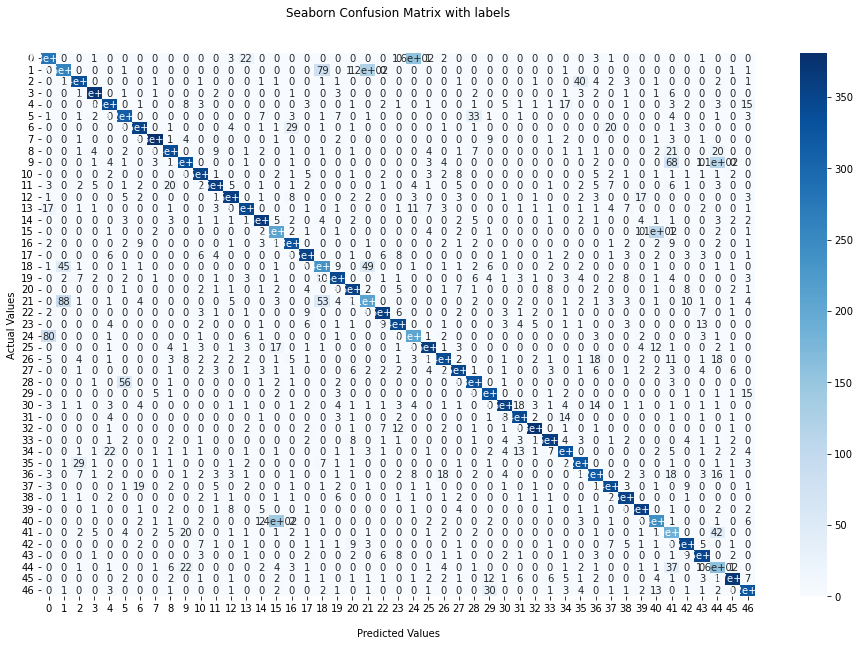

In [8]:
y_pred = mlp1.predict(X_test)

plt.figure(figsize=(16,10))
cm = confusion_matrix(y_pred, y_test)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.show()

Evaluation of MNIST + EMNIST MLP:

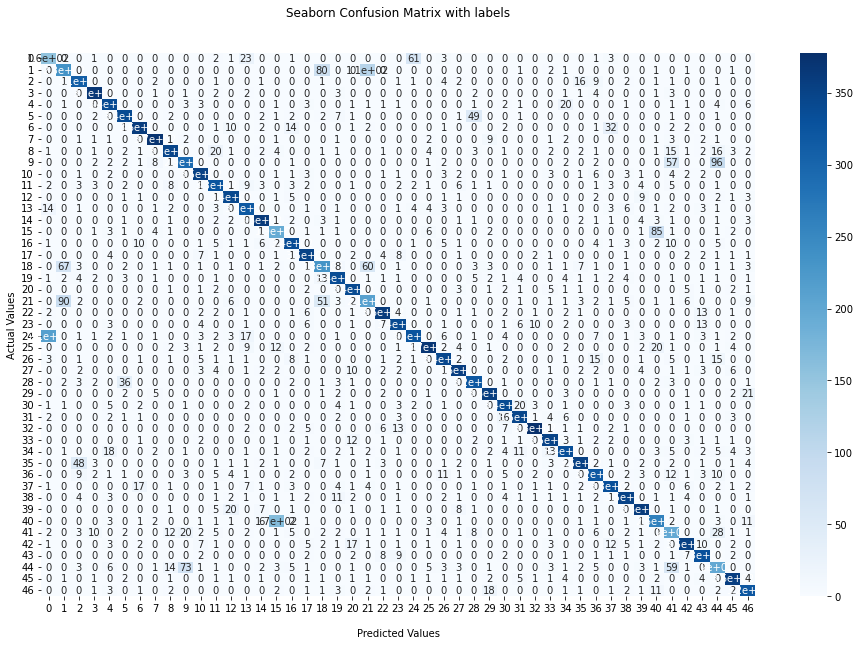

In [9]:
y_pred = mlp2.predict(X_test)

plt.figure(figsize=(16,10))
cm = confusion_matrix(y_pred, y_test)
ax = sns.heatmap(cm, annot=True, cmap='Blues')
ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values');
plt.show()